# # Monte Carlo Simulation for MCV1 Forecasts
# This notebook runs Monte Carlo simulations to provide probabilistic forecasts and prediction intervals.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import warnings
warnings.filterwarnings("ignore")

# Import core forecasting logic
import sys
sys.path.append('.')
from mcv1_forecast.core import train_model, recursive_forecast, COUNTRIES, TARGET

# ## Load Data and Train Base Model

In [6]:
# Load data
df_raw = pd.read_csv(r"D:\Home\Desktop\mcv1_final\backend\vaccine_data.csv")
future_demo_df = pd.read_csv(r"D:\Home\Desktop\mcv1_final\backend\future_demographics.csv")

# Train baseline model
model, df_engineered, feature_cols, dummy_cols = train_model(df_raw)

TimeSeries CV MAE Scores: [10.36511103  7.43322898 13.87630015]
Average CV MAE: 10.558


# ## Monte Carlo Engine

In [7]:
class MonteCarloEngine:
    def __init__(self, model, df_engineered, feature_cols, dummy_cols,
                 n_simulations=5000, random_seed=42):
        self.model = model
        self.df_engineered = df_engineered
        self.feature_cols = feature_cols
        self.dummy_cols = dummy_cols
        self.n_simulations = n_simulations
        self.rng = np.random.RandomState(random_seed)
        self.country_scale = {}
        self.pooled_residuals = np.array([])
        
        # Pool MAD-standardized residuals across countries
        self._prepare_residual_pool()
        
    def _prepare_residual_pool(self):
        """Compute MAD-standardized residuals per country and pool them."""
        backtest_results = recursive_forecast(
            self.df_engineered, self.model, self.feature_cols,
            self.dummy_cols, 2020, TARGET
        )
        backtest_results = backtest_results.dropna(subset=['Actual', 'Predicted'])
        backtest_results['Residual'] = backtest_results['Actual'] - backtest_results['Predicted']
        
        all_standardized = []
        for country in COUNTRIES:
            res = backtest_results[backtest_results['Country'] == country]['Residual'].values
            if len(res) > 1:
                mad = median_abs_deviation(res, scale='normal')
                if mad == 0:
                    mad = max(np.max(np.abs(res)), 1e-6)
                med = np.median(res)
                self.country_scale[country] = mad
                z = (res - med) / mad
                all_standardized.append(z)
            else:
                self.country_scale[country] = 5.0
        
        if len(all_standardized) > 0:
            self.pooled_residuals = np.concatenate(all_standardized)
        else:
            self.pooled_residuals = np.array([0.0])

    def _block_bootstrap(self, n, country):
        """Draw a length-n noise vector via moving block bootstrap.
        
        Resamples contiguous blocks from the pooled standardized residuals,
        then rescales by the target country's MAD scale.
        """
        pool = self.pooled_residuals
        pool_len = len(pool)
        block_len = max(2, int(np.sqrt(pool_len)))
        samples = []
        while len(samples) < n:
            start = self.rng.randint(0, pool_len - block_len + 1)
            samples.extend(pool[start:start + block_len])
        samples = np.array(samples[:n])
        return samples * self.country_scale[country]

    def perturb_demographics(self, demo_df):
        """Apply correlated perturbations to demographic inputs."""
        perturbed_df = demo_df.copy()
        
        for idx, row in perturbed_df.iterrows():
            births_mult = self.rng.normal(1.0, 0.05)
            imr_mult = self.rng.normal(1.0, 0.10)
            
            perturbed_df.at[idx, 'Births (thousands)'] *= births_mult
            perturbed_df.at[idx, 'Pop_Age_0(In Thousands)'] *= births_mult
            perturbed_df.at[idx, 'Infant Mortality Rate (infant deaths per 1,000 live births)'] *= imr_mult
            perturbed_df.at[idx, 'Under-Five Mortality (deaths under age 5 per 1,000 live births)'] *= imr_mult
            
        return perturbed_df

    def run_simulations(self, future_demo_df):
        """Run N simulations for all countries."""
        all_results = []
        
        print(f"Running {self.n_simulations} simulations...")
        for sim_id in range(self.n_simulations):
            if sim_id % 500 == 0:
                print(f"  Simulation {sim_id}/{self.n_simulations}")
                
            # 1. Perturb demographics
            sim_demo_df = self.perturb_demographics(future_demo_df)
            
            # 2. Run deterministic recursive forecast with perturbed demographics
            sim_pred = recursive_forecast(
                self.df_engineered, self.model, self.feature_cols,
                self.dummy_cols, 2025, TARGET, sim_demo_df
            )
            
            # 3. Add residual noise via block bootstrap
            for country in COUNTRIES:
                country_mask = sim_pred['Country'] == country
                n_years = country_mask.sum()
                if n_years > 0:
                    noise = self._block_bootstrap(n_years, country)
                    sim_pred.loc[country_mask, 'Predicted'] += noise
                    sim_pred.loc[country_mask, 'Predicted'] = sim_pred.loc[
                        country_mask, 'Predicted'
                    ].clip(lower=0, upper=150)
                    
            sim_pred['Simulation_ID'] = sim_id
            all_results.append(sim_pred)
            
        return pd.concat(all_results, ignore_index=True)

    def compute_percentiles(self, sim_results):
        """Aggregate simulation results into percentile bands."""
        percentiles = [5, 10, 25, 50, 75, 90, 95]
        
        def pct_func(p):
            return lambda x: np.percentile(x, p)
            
        agg_funcs = {f'P{p}': pct_func(p) for p in percentiles}
        agg_funcs['Mean'] = 'mean'
        
        grouped = sim_results.groupby(['Country', 'Year'])['Predicted'].agg(
            **agg_funcs
        ).reset_index()
        return grouped

# ## Run Simulations

In [8]:
engine = MonteCarloEngine(model, df_engineered, feature_cols, dummy_cols, n_simulations=1000)
sim_results = engine.run_simulations(future_demo_df)
percentiles_df = engine.compute_percentiles(sim_results)

Running 1000 simulations...
  Simulation 0/1000
  Simulation 500/1000


# ## Visualizations

In [9]:
def plot_fan_chart(percentiles_df, hist_df, country):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Historical data
    country_hist = hist_df[hist_df['Country'] == country]
    ax.plot(country_hist['Year'], country_hist[TARGET], 'ko-', label='Historical')
    
    # Forecast data
    country_pct = percentiles_df[percentiles_df['Country'] == country]
    years = country_pct['Year']
    
    # Connect last historical point to forecast
    last_hist_year = country_hist['Year'].max()
    last_hist_val = country_hist[TARGET].iloc[-1]
    
    years_plot = np.insert(years.values, 0, last_hist_year)
    
    p5 = np.insert(country_pct['P5'].values, 0, last_hist_val)
    p25 = np.insert(country_pct['P25'].values, 0, last_hist_val)
    p50 = np.insert(country_pct['P50'].values, 0, last_hist_val)
    p75 = np.insert(country_pct['P75'].values, 0, last_hist_val)
    p95 = np.insert(country_pct['P95'].values, 0, last_hist_val)
    
    # Plot bands
    ax.fill_between(years_plot, p5, p95, color='blue', alpha=0.1, label='90% CI (P5-P95)')
    ax.fill_between(years_plot, p25, p75, color='blue', alpha=0.3, label='50% CI (P25-P75)')
    ax.plot(years_plot, p50, 'b-', linewidth=2, label='Median Forecast (P50)')
    
    ax.set_title(f"Monte Carlo MCV1 Forecast - {country}")
    ax.set_xlabel("Year")
    ax.set_ylabel("MCV1 Target")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

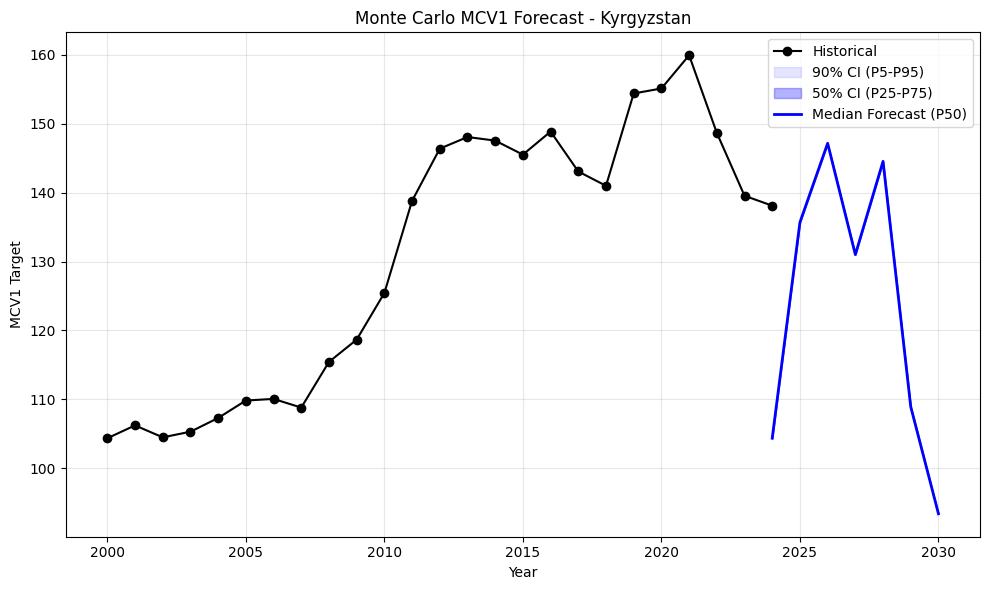

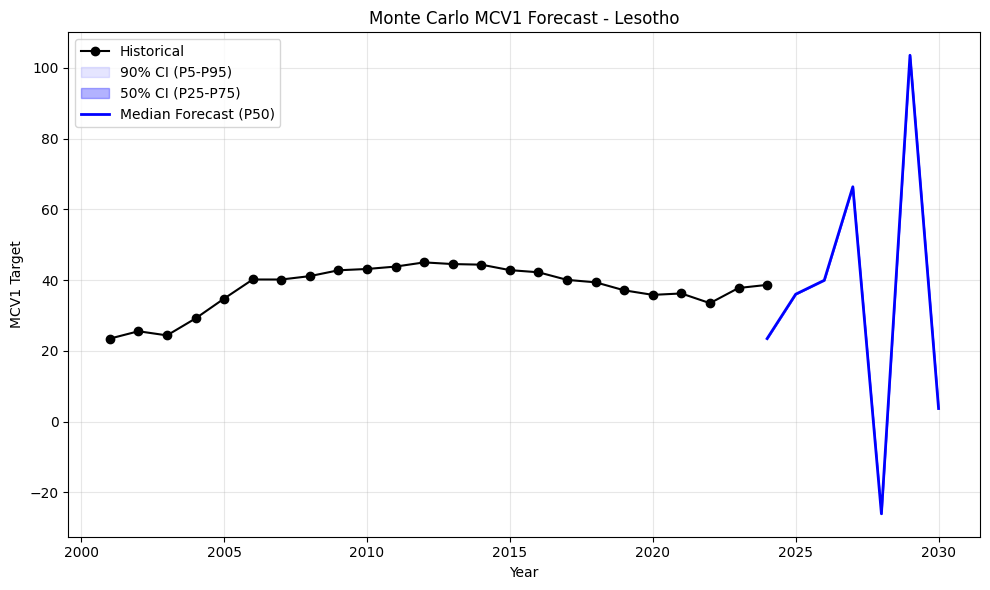

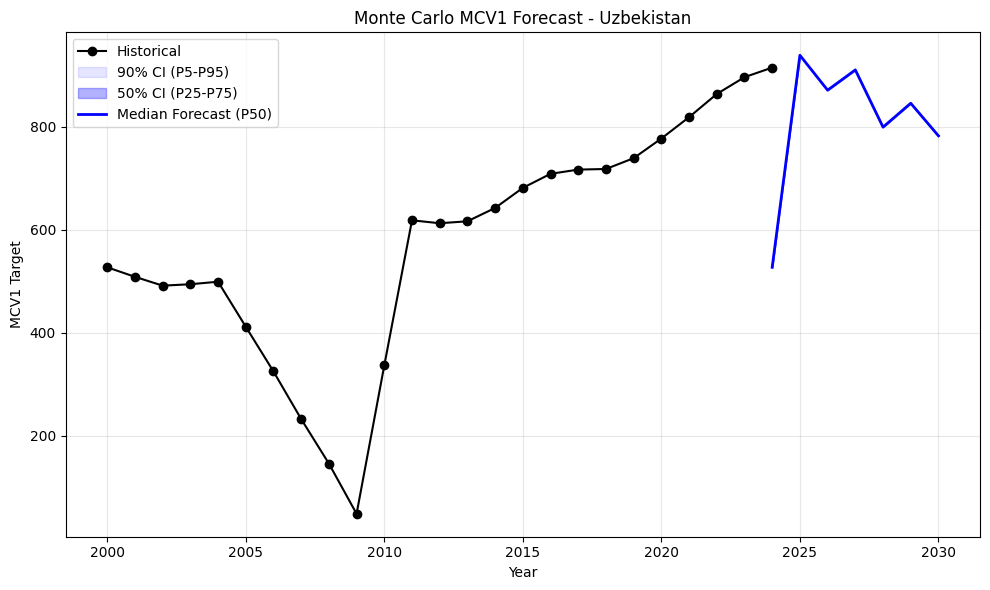

In [ ]:
for country in COUNTRIES:
    plot_fan_chart(percentiles_df, df_raw, country)